# STFateFlow on ARTISTA Regeneration

In [1]:
# Optional: run once if dependencies are missing in current kernel.
# You can uncomment the pip lines if needed.
# %pip install anndata scanpy torch torch-geometric torchcfm torchdyn tqdm matplotlib
from __future__ import annotations

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import importlib
import math
import sys
from pathlib import Path

repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from core.utils.inference import (
    bidirectional_nn_metrics,
    canonical_time_order,
    find_time_key,
    nn_of_x_in_y,
    wasserstein_distance,
)

required = [
    'anndata',
    'numpy',
    'torch',
    'matplotlib',
    'torch_geometric',
    'torchcfm',
    'torchdyn',
    # 'nicheflow',
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)


SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_float32_matmul_precision('high')

if not torch.cuda.is_available():
    raise RuntimeError('未检测到 CUDA GPU。请切换到可用 GPU 的环境后再训练。')

device = torch.device('cuda:1')
print('device =', device)
print('cuda name =', torch.cuda.get_device_name(0))


device = cuda:1
cuda name = NVIDIA A800 80GB PCIe


In [2]:
# -----------------------------
# User configurable parameters
# -----------------------------
h5ad_fp = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ARTISTA/Regeneration_affine_preprocessed_ae.h5ad')
work_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration')
work_dir.mkdir(parents=True, exist_ok=True)

coord_obsm_key = 'X_spatial_input'

print('h5ad path:', h5ad_fp)
print('output dir:', work_dir)


h5ad path: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ARTISTA/Regeneration_affine_preprocessed_ae.h5ad
output dir: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration


In [3]:
adata = ad.read_h5ad(h5ad_fp)
print('adata shape:', adata.shape)
print('obsm keys:', list(adata.obsm.keys()))

import scanpy as sc

sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, batch_key='Batch')

# Map user-provided spatial coordinates to the expected key.
# Gene features are read directly from adata.X by InfiniteGlobalRPCDataset.
adata.obsm['spatial'] = np.asarray(adata.obsm[coord_obsm_key], dtype=np.float32)

timepoint_col = 'time'
cell_type_col = 'Annotation'

if str(adata.obs[cell_type_col].dtype) != 'category':
    adata.obs[cell_type_col] = adata.obs[cell_type_col].astype('category')

timepoints_ordered = canonical_time_order(adata.obs[timepoint_col].dropna().unique())

print('timepoint column:', timepoint_col)
print('cell type column:', cell_type_col)
print('ordered timepoints:', timepoints_ordered)


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


adata shape: (46189, 16379)
obsm keys: ['X_ae', 'X_gene_input', 'X_pca', 'X_spatial', 'X_spatial_input', 'spatial']
timepoint column: time
cell type column: Annotation
ordered timepoints: [np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]


/data/yuz/envs/nicheflow/lib/python3.11/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Interpolation-CFM (real t0 source + velocity field supervision)

This section trains a new model with:
1. source state from real t0 data,
2. input as interpolation state between t0 and t1,
3. target as instantaneous velocity field from the interpolation path derivative.

In [4]:
import importlib

import torch


ds_mod = importlib.import_module("core.datasets.model_dataset")
pc_vf_mod = importlib.import_module("core.models.backbones.pc_transformer")
flow_mod = importlib.import_module("core.models.STFateFlow")

# pc_vf_mod = importlib.reload(pc_vf_mod)
# flow_mod = importlib.reload(flow_mod)
# ds_mod = importlib.reload(ds_mod)

stfateflowdataset = ds_mod.STFateFlowDataset
stfateflow_collate = ds_mod.stfateflow_collate
PointCloudTransformer = pc_vf_mod.PointCloudTransformer
stfateflow_model = flow_mod.STFateFlow_Module

In [5]:
test_timepoint = -1.0

flow_ckpt_fp = work_dir / 'artista_gene_interp.pt'
size_per_slice = 4096
train_num_workers = 4
batch_size = 2
num_steps_ode = 20
# Mixed precision on GPU: 'bf16' or 'fp16'
amp_dtype = 'bf16'

# Suggestion #1: default to soft-gating during inference.
dataset_name = 'artista'
fgw_alpha = 0.5
pi_cache_dir = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis')
pi_cache_path = pi_cache_dir / f'fgwot_pi_{dataset_name}_alpha{fgw_alpha}_gene_triu.npz'

dataset = stfateflowdataset(
    adata=adata,
    timepoint_column=timepoint_col,
    cell_type_column=cell_type_col,
    timepoints_ordered=timepoints_ordered,
    seed=SEED,
    size_per_slice=size_per_slice,
    ot_plan_cache_path= pi_cache_path,
    ot_plan_normalize=True,
    test_timepoint=test_timepoint,
)

train_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    num_workers=train_num_workers,
    pin_memory=True,
    persistent_workers=(train_num_workers > 0),
    collate_fn=stfateflow_collate,
)

n_genes = adata.n_vars
n_slices = len(timepoints_ordered)

backbone = PointCloudTransformer(
    gene_dim=n_genes,
    coord_dim=2
)

lambda_features=0.1
lambda_pos=1.0
lambda_cdm=10.0
stfateflow = stfateflow_model(
    lambda_features=lambda_features,
    lambda_pos=lambda_pos,
    lambda_cdm=lambda_cdm,
    backbone=backbone,
    num_steps=num_steps_ode,
    spatial_loss_type="l1"
).to(device)


# Training hyperparameters
lr = 3e-4
weight_decay = 1e-5
max_grad_norm = 1.0
optimizer = torch.optim.AdamW(stfateflow.parameters(), lr=lr, weight_decay=weight_decay)

autocast_dtype = torch.bfloat16 if amp_dtype == 'bf16' else torch.float16
use_scaler = amp_dtype == 'fp16'
scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
print('lr =', lr, 'max_grad_norm =', max_grad_norm, 'amp_dtype =', amp_dtype, 'use_scaler =', use_scaler)


lr = 0.0003 max_grad_norm = 1.0 amp_dtype = bf16 use_scaler = False


/data/yuz/tmp/ipykernel_2571118/3755315073.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)


Training STFateFlow (balanced):   0%|          | 0/4000 [00:00<?, ?it/s]

Saved STFateFlow checkpoint: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration/artista_gene_interp_5.pt


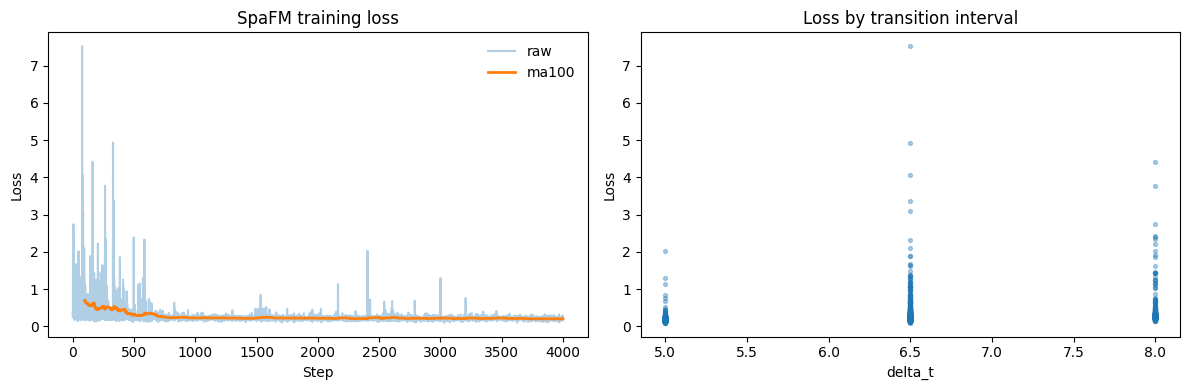

In [13]:
stfateflow.train()
stfateflow_iter = iter(train_loader)
stfateflow_loss_hist = []
stfateflow_diag_hist = []
train_steps = 1000
stfateflow_pbar = tqdm(range(train_steps), desc='Training STFateFlow (balanced)')
for step in stfateflow_pbar:

    batch = next(stfateflow_iter)
    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type='cuda', dtype=autocast_dtype, enabled=True):
        losses = stfateflow.loss(batch)
        loss = losses['loss']

    if use_scaler:
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(stfateflow.parameters(), max_grad_norm)
        optimizer.step()

    stfateflow_loss_hist.append(float(loss.detach().cpu()))
    stfateflow_diag_hist.append(
        {
            'loss': float(loss.detach().cpu()),
            'loss_x': float(losses['loss_x'].detach().cpu()),
            'loss_pos': float(losses['loss_pos'].detach().cpu()),
            'loss_cdm': float(losses['loss_cdm'].detach().cpu()),
            'weighted_loss_cdm': float(losses['weighted_loss_cdm'].detach().cpu()),
            'weighted_loss_pos': float(losses['weighted_loss_pos'].detach().cpu()),
            'grad_norm': float(torch.as_tensor(grad_norm).detach().cpu()),
            'delta_t': float(batch['delta_t'].mean().detach().cpu()),
            't0_raw': tuple(float(v) for v in batch['t0_raw'].detach().cpu().tolist()),
            't1_raw': tuple(float(v) for v in batch['t1_raw'].detach().cpu().tolist()),
        }
    )

torch.save(
    {
        'flow_state_dict': stfateflow.state_dict(),
        'n_genes': n_genes,
        'n_slices': n_slices,
        'timepoints_ordered': timepoints_ordered,
        'config': {
            'model': 'STFateFlow_khead_balanced',
            'size_per_slice': size_per_slice,
            'train_steps': train_steps,
            'lr': lr,
            'weight_decay': weight_decay,
            'max_grad_norm': max_grad_norm,
            'amp_dtype': amp_dtype,
            'num_steps_ode': num_steps_ode,
            'lambda_features': lambda_features,
            'lambda_pos': lambda_pos,
            'lambda_cdm': lambda_cdm,
            'spatial_loss_type': stfateflow.spatial_loss_type,
        },
    },
    flow_ckpt_fp,
)
print('Saved STFateFlow checkpoint:', flow_ckpt_fp)

loss_arr = np.asarray(stfateflow_loss_hist, dtype=np.float64)
window = min(100, max(1, len(loss_arr)))
ma = np.convolve(loss_arr, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_arr, alpha=0.35, label='raw')
axes[0].plot(np.arange(window - 1, window - 1 + len(ma)), ma, linewidth=2, label=f'ma{window}')
axes[0].set_title('STFateFlow training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=False)

diag_delta_t = np.asarray([d['delta_t'] for d in stfateflow_diag_hist], dtype=np.float64)
axes[1].scatter(diag_delta_t, loss_arr, s=8, alpha=0.35)
axes[1].set_title('Loss by transition interval')
axes[1].set_xlabel('delta_t')
axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.show()


In [6]:
# Load a trained STFateFlow checkpoint. Run this cell after the setup/model-definition cell to skip retraining.
from core.models.checkpointing import load_stfateflow_checkpoint
flow_ckpt_fp = work_dir / 'artista_gene_interp.pt'

if not flow_ckpt_fp.exists():
    raise FileNotFoundError(f'STFateFlow checkpoint not found: {flow_ckpt_fp}. Run the training cell once first.')

n_genes = adata.n_vars
num_steps_ode = 20
stfateflow, stfateflow_load_info = load_stfateflow_checkpoint(
    flow_ckpt_fp,
    device=device,
    gene_dim=n_genes,
    coord_dim=2,
    num_steps=num_steps_ode,
    strict=False,
)
stfateflow.eval()

print(f'Loaded STFateFlow checkpoint: {flow_ckpt_fp}')
if stfateflow_load_info['missing_keys']:
    print('Missing keys:', stfateflow_load_info['missing_keys'])
if stfateflow_load_info['unexpected_keys']:
    print('Unexpected keys:', stfateflow_load_info['unexpected_keys'])


Loaded STFateFlow checkpoint: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/data/artista_regeneration/artista_gene_interp.pt


In [ ]:
from core.models.cell_type_classifier import CellTypeClassifierInterface

ct_clf = CellTypeClassifierInterface(
    adata=adata,
    gene_key="X",
    coord_key=coord_obsm_key,
    label_key=cell_type_col,
    hidden_dim=256,
    depth=4,
    time_embed_dim=64,
    dropout=0.1,
    device="cuda:0",
)

In [10]:
save_path = work_dir / "ARTISTA_cell_type_classifier.pt"
history = ct_clf.train(
    adata,
    gene_key="X",
    coord_key=coord_obsm_key,
    time_key="time",
    label_key=cell_type_col,
    epochs=100,
    batch_size=1024,
    lr=1e-3,
    save_path=save_path,
)

In [12]:
ds_mod = importlib.reload(ds_mod)

stfateflow.eval()

size_per_slice = 4096

source_timepoint = 10.0
target_timepoint = 15.0
interpolation_timepoint = -1.0

t1_key = find_time_key(timepoints_ordered, source_timepoint)
t2_key = find_time_key(timepoints_ordered, target_timepoint)

source_pc = dataset.timepoint_pc[t1_key]
target_pc = dataset.timepoint_pc[t2_key]

X_t0 = source_pc.x.unsqueeze(0).to(device)
pos_t0 = source_pc.pos.unsqueeze(0).to(device)

n_cells = X_t0.size(1)
sample_t_start = float(source_pc.t_value.item())
sample_t_end = float(target_pc.t_value.item()) if interpolation_timepoint < 0 else float(interpolation_timepoint) - dataset.time_origin
print('sample_t_start =', sample_t_start, 'sample_t_end =', sample_t_end)

with torch.no_grad():
    sample_out = stfateflow.sample(
        X_t0=X_t0,
        pos_t0=pos_t0,
        t_start=sample_t_start,
        t_end=sample_t_end,
    )

    # Compatible with both return styles:
    # 1) tuple/list: (x_traj, pos_traj)
    # 2) dict: {'x_traj': ..., 'pos_traj': ...}
    if isinstance(sample_out, dict):
        x_traj = sample_out.get('x_traj', None)
        pos_traj = sample_out.get('pos_traj', None)
        potential_traj = sample_out.get('potential_traj', None)

    last_x = x_traj[-1] if isinstance(x_traj, (list, tuple)) else x_traj
    last_pos = pos_traj[-1] if isinstance(pos_traj, (list, tuple)) else pos_traj

    pred_x_interp = last_x.reshape(-1, n_genes).detach().cpu().numpy()
    coord_dim = int(pos_t0.shape[-1])
    pred_pos_interp = last_pos.reshape(-1, coord_dim).detach().cpu().numpy()

# Source potential/velocity visualization is in the next cell.


sample_t_start = 8.0 sample_t_end = 13.0


In [ ]:
ckpt_path = work_dir / "ARTISTA_cell_type_classifier.pt"
ct_clf = CellTypeClassifierInterface(
    ckpt_path=ckpt_path,
    device="cuda:0",
)

In [54]:
import anndata as ad
output_dir = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/experiments/results/'
test_adata = adata[adata.obs['time'] == target_timepoint]
pred_adata = ad.AnnData(X=pred_x_interp)
pred_adata.obsm['pred_spatial'] = pred_pos_interp
# pred_adata.obsm['X_spatial_input'] = pred_pos_interp
pred_adata.obs['time'] = float(target_timepoint)

pred_cell_type = ct_clf.predict(
    pred_adata,
    gene_key="X",
    coord_key='pred_spatial',
    time_key="time",
    return_cell_type=True
)

pred_adata.obs['cell_type'] = pred_cell_type

In [ ]:
output_file = f'ARTISTA_stfateflow_interpolated_time_{int(interpolation_timepoint)}.h5ad'
output_path = output_dir + output_file
pred_adata.write_h5ad(output_path)


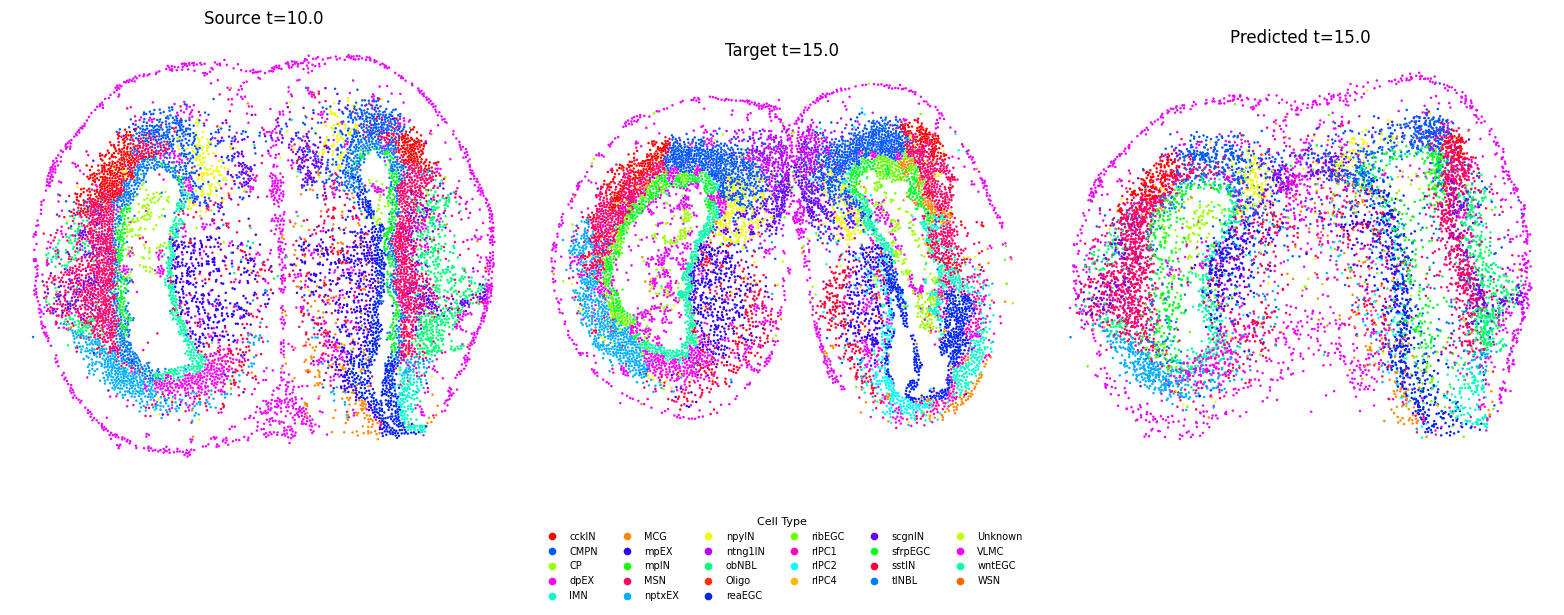

In [58]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_hex

def build_global_cell_type_palette(adata, annotation_key="Annotation"):
    if str(adata.obs[annotation_key].dtype) == "category":
        cell_types = [str(x) for x in adata.obs[annotation_key].cat.categories]
    else:
        cell_types = sorted(adata.obs[annotation_key].astype(str).unique())

    hues = (np.arange(len(cell_types)) * 0.618033988749895) % 1.0
    colors = [to_hex(plt.cm.hsv(h)[:3]) for h in hues]
    return dict(zip(cell_types, colors))

cell_type_palette = build_global_cell_type_palette(adata, annotation_key="Annotation")
all_cell_types = list(cell_type_palette.keys())

def colors_from_cell_types(cell_types, palette):
    return np.asarray([palette[str(ct)] for ct in cell_types], dtype=object)

def cell_types_at_time(adata, time_value, time_key="time", annotation_key="Annotation"):
    idx = np.asarray(np.where(adata.obs[time_key] == time_value)[0])
    return adata.obs.iloc[idx][annotation_key].astype(str).to_numpy()

def style_spatial_axis(ax, title):
    ax.set_facecolor("white")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, color="black", fontsize=12, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
        spine.set_visible(False)

def plot_source_target_pred(
    source_pos,
    source_cell_types,
    target_pos,
    target_cell_types,
    pred_pos,
    pred_cell_types,
    palette,
    point_size=3.2,
    save=True,
):
    panels = [
        (source_pos, source_cell_types, f"Source t={source_timepoint}"),
        (target_pos, target_cell_types, f"Target t={target_timepoint}"),
        (pred_pos, pred_cell_types, f"Predicted t={target_timepoint}"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 6.0), facecolor="white")
    for ax, (points, cell_types, title) in zip(axes, panels):
        ax.scatter(
            points[:, 0],
            points[:, 1],
            s=point_size,
            alpha=1.0,
            c=colors_from_cell_types(cell_types, palette),
            marker="o",
            edgecolors="none",
            linewidths=0,
        )
        style_spatial_axis(ax, title)

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=5.5,
            markerfacecolor=palette[ct],
            markeredgecolor="none",
            label=ct,
        )
        for ct in all_cell_types
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=6,
        frameon=False,
        title="Cell Type",
        fontsize=7,
        title_fontsize=8,
        markerscale=1.0,
    )
    plt.tight_layout(rect=[0, 0.16, 1, 1], pad=0.2, w_pad=0.8)

    if save:
        save_path = work_dir / f"source_target_pred_t{source_timepoint}_to_t{target_timepoint}.png"
        plt.savefig(save_path, dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()

source_pos = dataset.timepoint_pc[t1_key].pos.detach().cpu().numpy()
target_pos = dataset.timepoint_pc[t2_key].pos.detach().cpu().numpy()
pred_cell_types = pred_adata.obs["cell_type"].astype(str).to_numpy()
source_cell_types = cell_types_at_time(adata, t1_key, time_key=timepoint_col, annotation_key="Annotation")
target_cell_types = cell_types_at_time(adata, t2_key, time_key=timepoint_col, annotation_key="Annotation")

plot_source_target_pred(
    source_pos,
    source_cell_types,
    target_pos,
    target_cell_types,
    pred_pos_interp,
    pred_cell_types,
    palette=cell_type_palette,
)


2.0 5.0 Chamfer squared: 0.0008
2.0 5.0 Chamfer L2 mean: 0.0226
2.0 5.0 Chamfer RMSE: 0.0374
2.0 5.0 Hausdorff95: 0.0614
2.0 5.0 Hausdorff max: 0.1633
2.0 5.0 coord Wasserstein distance: 0.0865
annotation categories: 19


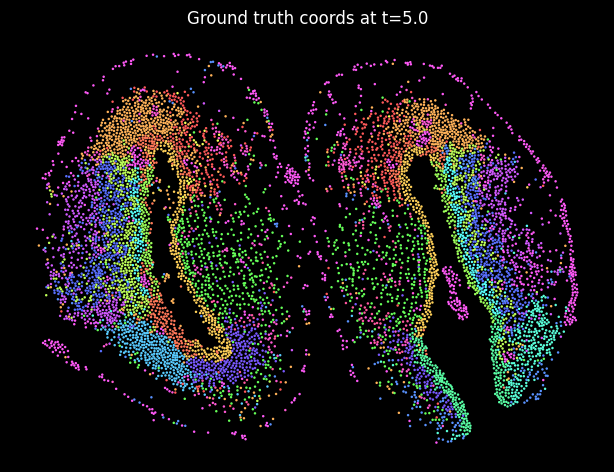

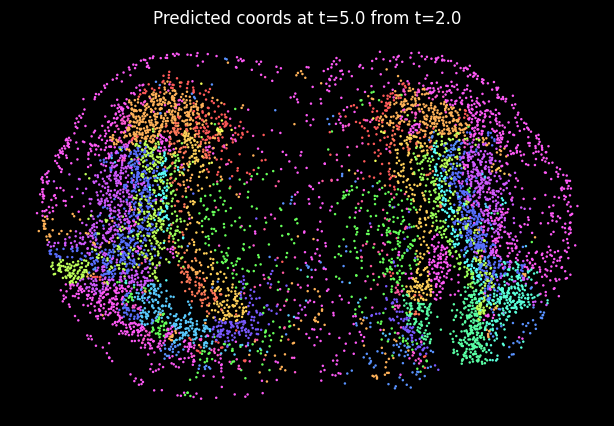

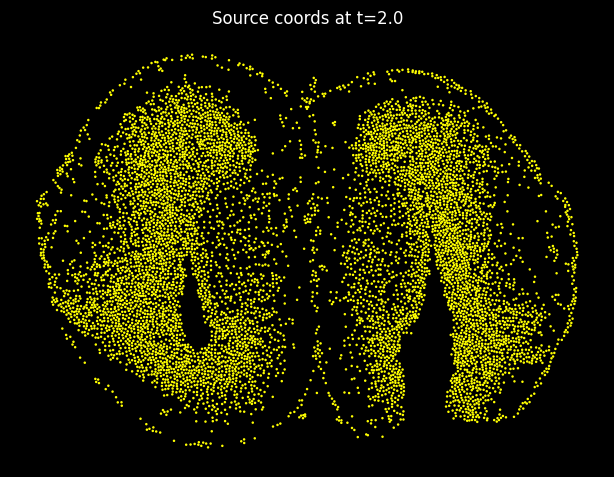

Cell Type legend:
  - CMPN
  - MCG
  - MSN
  - VLMC
  - WSN
  - cckIN
  - dpEX
  - mpEX
  - mpIN
  - nptxEX
  - npyIN
  - obNBL
  - reaEGC
  - ribEGC
  - scgnIN
  - sfrpEGC
  - sstIN
  - tlNBL
  - wntEGC


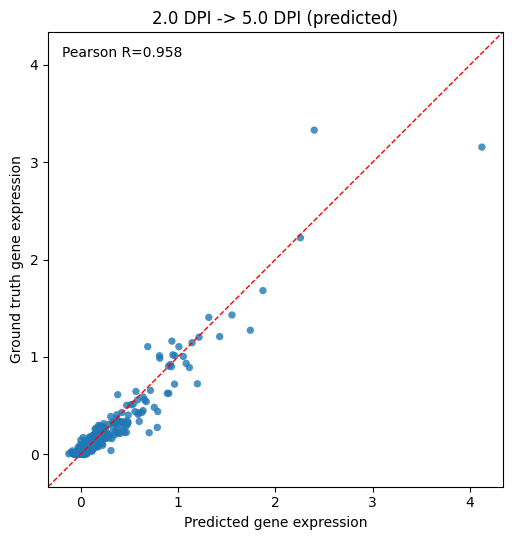

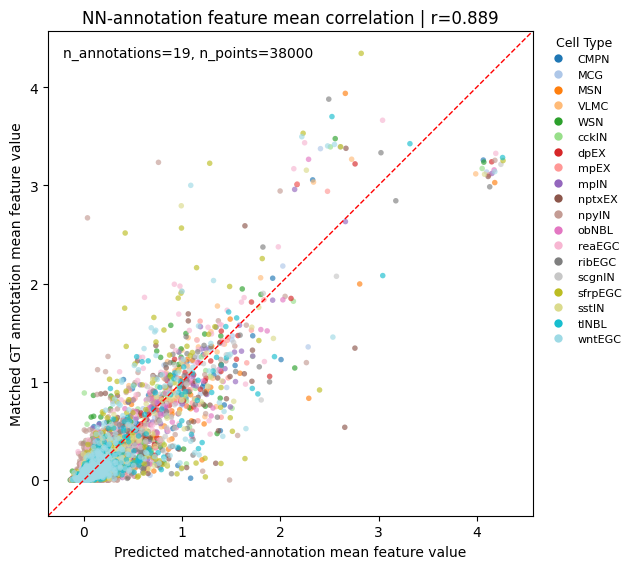

Feature mean correlation r = 0.9581
NN-annotation feature mean correlation r = 0.8887


In [16]:
t2_key = interpolation_timepoint if interpolation_timepoint >= 0 else t2_key

source_x = dataset.timepoint_pc[t1_key].x.detach().cpu().numpy()
source_pos = dataset.timepoint_pc[t1_key].pos.detach().cpu().numpy()

gt_x_interp = dataset.timepoint_pc[t2_key].x.detach().cpu().numpy()
gt_pos_interp = dataset.timepoint_pc[t2_key].pos.detach().cpu().numpy()

pred_pos_t = torch.tensor(pred_pos_interp, dtype=torch.float32)
gt_pos_t = torch.tensor(gt_pos_interp, dtype=torch.float32)
coord_metrics = bidirectional_nn_metrics(pred_pos_t, gt_pos_t)
idx_pred_to_gt_interp_t = coord_metrics['idx_x_to_y']
dist_pred_to_gt_interp_t = coord_metrics['dist_x_to_y']
idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
dist_pred_to_gt_interp = dist_pred_to_gt_interp_t.detach().cpu().numpy()

matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

chamfer_interp = float(coord_metrics['cd_sq'].detach().cpu())
chamfer_l2_interp = float(coord_metrics['cd_l2'].detach().cpu())
chamfer_rmse_interp = float(coord_metrics['cd_rmse'].detach().cpu())
hausdorff95_interp = float(coord_metrics['hd95'].detach().cpu())
hausdorff_interp = float(coord_metrics['hd'].detach().cpu())

pos_interp_wass = float(
    wasserstein_distance(
        torch.tensor(gt_pos_interp, dtype=torch.float32),
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        power=1,
    )
)

# 读取 target 时间点的 annotation，并用于 GT / Pred 着色（Pred 使用匹配到的 GT 注释）
if 'Annotation' not in adata.obs.columns:
    raise KeyError("Missing adata.obs['Annotation']; please check annotation column name.")

target_global_indices = np.asarray(np.where(adata.obs[timepoint_col] == t2_key)[0])
gt_annotation_interp = adata.obs.iloc[target_global_indices]['Annotation'].astype(str).to_numpy()
if gt_annotation_interp.shape[0] != gt_pos_interp.shape[0]:
    n_min = min(gt_annotation_interp.shape[0], gt_pos_interp.shape[0])
    print(
        f"Warning: annotation count ({gt_annotation_interp.shape[0]}) != target cell count ({gt_pos_interp.shape[0]}), truncating to {n_min}."
    )
    gt_annotation_interp = gt_annotation_interp[:n_min]
    gt_pos_interp = gt_pos_interp[:n_min]
    gt_x_interp = gt_x_interp[:n_min]
    idx_pred_to_gt_interp_t, dist_pred_to_gt_interp_t = nn_of_x_in_y(
        torch.tensor(pred_pos_interp, dtype=torch.float32),
        torch.tensor(gt_pos_interp, dtype=torch.float32),
    )
    idx_pred_to_gt_interp = idx_pred_to_gt_interp_t.detach().cpu().numpy()
    matched_gt_x_interp = gt_x_interp[idx_pred_to_gt_interp]

matched_gt_annotation_interp = gt_annotation_interp[idx_pred_to_gt_interp]
# Temporary visualization label: nearest GT annotation, not a model prediction.
pred_annotation_interp = matched_gt_annotation_interp

ann_levels = np.unique(np.concatenate([gt_annotation_interp, pred_annotation_interp]))
ann_to_idx = {ann: i for i, ann in enumerate(ann_levels)}
gt_color_idx = np.asarray([ann_to_idx[a] for a in gt_annotation_interp], dtype=int)
pred_color_idx = np.asarray([ann_to_idx[a] for a in pred_annotation_interp], dtype=int)

n_ann = len(ann_levels)
if n_ann <= 0:
    ann_colors = np.asarray(['#ffffff'], dtype=object)
else:
    # Generate one bright color per annotation. Golden-ratio hue spacing keeps
    # neighboring annotation ids from receiving overly similar colors.
    hues = (np.arange(n_ann) * 0.618033988749895) % 1.0
    rgb = plt.cm.hsv(hues)[:, :3]
    ann_colors = 0.35 + 0.65 * rgb
ann_cmap = ListedColormap(ann_colors)
gt_point_colors = ann_colors[gt_color_idx]
pred_point_colors = ann_colors[pred_color_idx]

print(f'{source_timepoint} {t2_key} Chamfer squared: {chamfer_interp:.4f}')
print(f'{source_timepoint} {t2_key} Chamfer L2 mean: {chamfer_l2_interp:.4f}')
print(f'{source_timepoint} {t2_key} Chamfer RMSE: {chamfer_rmse_interp:.4f}')
print(f'{source_timepoint} {t2_key} Hausdorff95: {hausdorff95_interp:.4f}')
print(f'{source_timepoint} {t2_key} Hausdorff max: {hausdorff_interp:.4f}')
print(f'{source_timepoint} {t2_key} coord Wasserstein distance: {pos_interp_wass:.4f}')
print(f'annotation categories: {n_ann}')

def plot_spatial_annotation(points, point_colors, title, point_size=3.2, show_axes=False):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6), facecolor='black')
    ax.set_facecolor('black')
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=point_size,
        alpha=1.0,
        c=point_colors,
        marker='o',
        edgecolors='none',
        linewidths=0,
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, color='white', fontsize=12, pad=8)
    if show_axes:
        ax.set_xlabel('x', color='white')
        ax.set_ylabel('y', color='white')
        ax.tick_params(axis='both', colors='white')
        for spine in ax.spines.values():
            spine.set_color('white')
    else:
        ax.set_axis_off()
    plt.tight_layout(pad=0.2)
    plt.show()

plot_spatial_annotation(
    gt_pos_interp,
    gt_point_colors,
    f'Ground truth coords at t={t2_key}',
)
plot_spatial_annotation(
    pred_pos_interp,
    pred_point_colors,
    f'Predicted coords at t={t2_key} from t={source_timepoint}',
)

plot_spatial_annotation(
    source_pos,
    '#ffff00',
    f'Source coords at t={t1_key}',
)

shown = ann_levels
print('Cell Type legend:')
for a in shown:
    print(f'  - {a}')

# Feature correlation from sample-averaged latent values.
# Each point in the first panel is one feature dimension.
def _safe_corrcoef(x, y):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    x = x[mask]
    y = y[mask]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

pred_feature_mean = pred_x_interp.mean(axis=0)
gt_feature_mean = matched_gt_x_interp.mean(axis=0)
feature_mean_corr = _safe_corrcoef(pred_feature_mean, gt_feature_mean)

feature_min = float(np.nanmin([pred_feature_mean.min(), gt_feature_mean.min()]))
feature_max = float(np.nanmax([pred_feature_mean.max(), gt_feature_mean.max()]))
feature_pad = 0.05 * max(feature_max - feature_min, 1e-8)
feature_lim = [feature_min - feature_pad, feature_max + feature_pad]

# Nearest-GT-annotation grouped feature correlation.
# Each point in the second panel is one (matched annotation, feature dimension) pair.
ct_pred_means = []
ct_gt_means = []
ct_labels = []
ct_levels = np.unique(pred_annotation_interp)
for ct in ct_levels:
    ct_mask = pred_annotation_interp == ct
    if not np.any(ct_mask):
        continue
    ct_pred_mean = pred_x_interp[ct_mask].mean(axis=0)
    ct_gt_mean = matched_gt_x_interp[ct_mask].mean(axis=0)
    ct_pred_means.append(ct_pred_mean)
    ct_gt_means.append(ct_gt_mean)
    ct_labels.extend([ct] * ct_pred_mean.shape[0])

if len(ct_pred_means) == 0:
    raise RuntimeError('No matched-annotation groups available for feature mean correlation plot.')

ct_pred_feature_mean = np.concatenate(ct_pred_means)
ct_gt_feature_mean = np.concatenate(ct_gt_means)
ct_labels = np.asarray(ct_labels)
ct_feature_mean_corr = _safe_corrcoef(ct_pred_feature_mean, ct_gt_feature_mean)

ct_feature_min = float(np.nanmin([ct_pred_feature_mean.min(), ct_gt_feature_mean.min()]))
ct_feature_max = float(np.nanmax([ct_pred_feature_mean.max(), ct_gt_feature_mean.max()]))
ct_feature_pad = 0.05 * max(ct_feature_max - ct_feature_min, 1e-8)
ct_feature_lim = [ct_feature_min - ct_feature_pad, ct_feature_max + ct_feature_pad]

ct_to_idx = {ct: i for i, ct in enumerate(ct_levels)}
ct_color_idx = np.asarray([ct_to_idx[ct] for ct in ct_labels], dtype=int)
ct_cmap = plt.get_cmap('tab20', max(len(ct_levels), 1)) if len(ct_levels) <= 20 else plt.get_cmap('gist_ncar', len(ct_levels))

fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.5))
ax.scatter(pred_feature_mean, gt_feature_mean, s=28, alpha=0.8, edgecolor='none')
ax.plot(feature_lim, feature_lim, 'r--', linewidth=1)
ax.set_xlim(feature_lim)
ax.set_ylim(feature_lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Predicted gene expression')
ax.set_ylabel('Ground truth gene expression')
ax.set_title(f'{t1_key} DPI -> {t2_key} DPI (predicted)')
ax.text(
    0.03,
    0.97,
    f'Pearson R={feature_mean_corr:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8.8, 5.8))
ax.scatter(
    ct_pred_feature_mean,
    ct_gt_feature_mean,
    c=ct_color_idx,
    cmap=ct_cmap,
    vmin=0,
    vmax=max(len(ct_levels) - 1, 1),
    s=16,
    alpha=0.65,
    edgecolor='none',
)
ax.plot(ct_feature_lim, ct_feature_lim, 'r--', linewidth=1)
ax.set_xlim(ct_feature_lim)
ax.set_ylim(ct_feature_lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Predicted matched-annotation mean feature value')
ax.set_ylabel('Matched GT annotation mean feature value')
ax.set_title(f'NN-annotation feature mean correlation | r={ct_feature_mean_corr:.3f}')
ax.text(
    0.03,
    0.97,
    f'n_annotations={len(ct_levels)}, n_points={ct_pred_feature_mean.shape[0]}',
    transform=ax.transAxes,
    va='top',
    ha='left',
)

ct_shown = ct_levels
ct_color_den = max(len(ct_levels) - 1, 1)
ct_handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        linestyle='',
        markersize=6,
        markerfacecolor=ct_cmap(ct_to_idx[ct] / ct_color_den),
        markeredgecolor='none',
        label=ct,
    )
    for ct in ct_shown
]

ax.legend(
    handles=ct_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
    title='Cell Type',
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

print(f'Feature mean correlation r = {feature_mean_corr:.4f}')
print(f'NN-annotation feature mean correlation r = {ct_feature_mean_corr:.4f}')


In [27]:
pred_x_interp

array([[ 2.8193330e-02,  3.9668873e-02,  1.1645546e-01, ...,
         3.5860442e-02,  6.0895756e-03, -6.8535239e-02],
       [ 3.1800900e-02,  2.4681685e-02,  1.3272288e-01, ...,
         2.7595546e-02,  5.7996348e-03, -6.8699934e-02],
       [ 4.8684780e-02,  5.2886043e-02,  1.1350163e-01, ...,
         3.3910692e-02,  1.1603639e-03, -7.6846093e-02],
       ...,
       [-8.6810077e-03,  1.6585162e-02,  4.7284253e-02, ...,
         8.7624870e-02,  3.4846883e-02,  2.6324282e+00],
       [ 7.0539519e-02,  4.7309455e-02,  1.5086143e-01, ...,
         2.6399974e-02,  2.0762880e-03, -4.2895909e-02],
       [ 2.0206034e-02,  5.9469808e-02,  1.3449819e-01, ...,
         6.2437173e-02, -1.5151818e-02, -1.8068019e-02]],
      shape=(8106, 2000), dtype=float32)

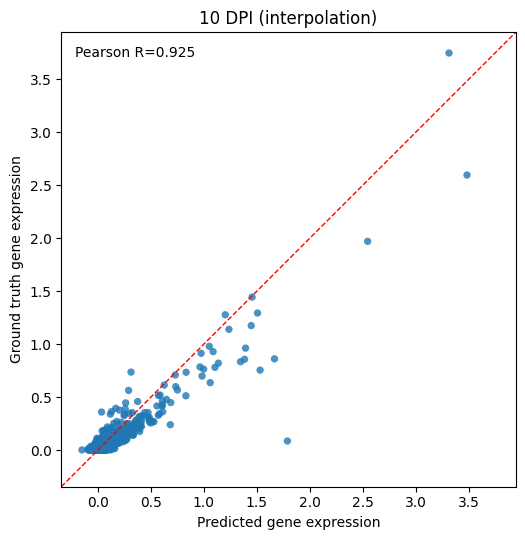

In [28]:
import scanpy as sc

pred_feature_mean = pred_x_interp.mean(axis = 0)
# pred_feature_mean = pred_feature_mean[None, :]
gt_feature_mean = adata[adata.obs['time']==10.0].X.mean(axis=0)
gt_feature_mean = np.array(gt_feature_mean)
feature_min = float(np.nanmin([pred_feature_mean.min(), gt_feature_mean.min()]))
feature_max = float(np.nanmax([pred_feature_mean.max(), gt_feature_mean.max()]))
feature_pad = 0.05 * max(feature_max - feature_min, 1e-8)
feature_lim = [feature_min - feature_pad, feature_max + feature_pad]
feature_mean_corr = np.corrcoef(pred_feature_mean, gt_feature_mean)[0,1]
fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.5))
ax.scatter(pred_feature_mean, gt_feature_mean, s=28, alpha=0.8, edgecolor='none')
ax.plot(feature_lim, feature_lim, 'r--', linewidth=1)
ax.set_xlim(feature_lim)
ax.set_ylim(feature_lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Predicted gene expression')
ax.set_ylabel('Ground truth gene expression')
ax.set_title(f'10 DPI (interpolation)')
ax.text(
    0.03,
    0.97,
    f'Pearson R={feature_mean_corr:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
)
plt.tight_layout()
plt.show()

# other methods experiment

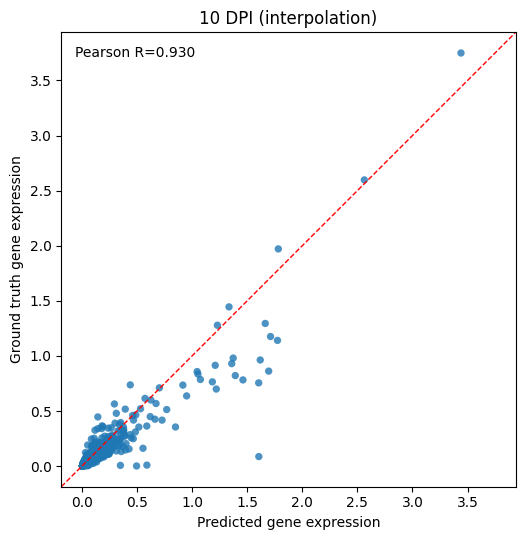

In [13]:
import scanpy as sc

stVCR_adata_in_10 = sc.read_h5ad('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow/experiments/results/stVCR_axolotl_in_10.h5ad')
pred_feature_mean = stVCR_adata_in_10.X.mean(axis = 0)
pred_feature_mean = pred_feature_mean[None, :]
gt_feature_mean = adata[adata.obs['time']==10.0].X.mean(axis=0)
gt_feature_mean = np.array(gt_feature_mean)
feature_min = float(np.nanmin([pred_feature_mean.min(), gt_feature_mean.min()]))
feature_max = float(np.nanmax([pred_feature_mean.max(), gt_feature_mean.max()]))
feature_pad = 0.05 * max(feature_max - feature_min, 1e-8)
feature_lim = [feature_min - feature_pad, feature_max + feature_pad]
feature_mean_corr = np.corrcoef(pred_feature_mean, gt_feature_mean)[0,1]
fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.5))
ax.scatter(pred_feature_mean, gt_feature_mean, s=28, alpha=0.8, edgecolor='none')
ax.plot(feature_lim, feature_lim, 'r--', linewidth=1)
ax.set_xlim(feature_lim)
ax.set_ylim(feature_lim)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Predicted gene expression')
ax.set_ylabel('Ground truth gene expression')
ax.set_title(f'10 DPI (interpolation)')
ax.text(
    0.03,
    0.97,
    f'Pearson R={feature_mean_corr:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import torch
from scipy import sparse
import ot

def to_numpy(x):
    if sparse.issparse(x):
        x = x.toarray()
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=np.float32)

def sample_rows(x, n=2000, seed=2026):
    rng = np.random.default_rng(seed)
    if x.shape[0] <= n:
        return x
    idx = rng.choice(x.shape[0], size=n, replace=False)
    return x[idx]

def median_heuristic_sigma(x, y, max_points=1000):
    xy = np.concatenate([x, y], axis=0)
    xy = sample_rows(xy, n=max_points)
    d = torch.cdist(torch.tensor(xy), torch.tensor(xy), p=2)
    vals = d[d > 0]
    return float(torch.median(vals).item())

def mmd_rbf(x, y, sigma=None):
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    if sigma is None:
        sigma = median_heuristic_sigma(x.numpy(), y.numpy())

    gamma = 1.0 / (2 * sigma ** 2)

    k_xx = torch.exp(-gamma * torch.cdist(x, x, p=2) ** 2).mean()
    k_yy = torch.exp(-gamma * torch.cdist(y, y, p=2) ** 2).mean()
    k_xy = torch.exp(-gamma * torch.cdist(x, y, p=2) ** 2).mean()

    return float((k_xx + k_yy - 2 * k_xy).item())

def sinkhorn_distance(x, y, reg=0.05):
    a = ot.unif(x.shape[0])
    b = ot.unif(y.shape[0])

    M = ot.dist(x, y, metric="euclidean")
    M = M / max(M.mean(), 1e-8)

    return float(ot.sinkhorn2(a, b, M, reg=reg))

# 1) collect arrays
ours_x = to_numpy(pred_x_interp)
stvcr_x = to_numpy(stVCR_adata_in_10.X)
gt_x = to_numpy(adata[adata.obs["time"] == 10.0].X)

# 2) optional subsample for speed/memory
n_eval = 2000
ours_eval = sample_rows(ours_x, n=n_eval, seed=2026)
stvcr_eval = sample_rows(stvcr_x, n=n_eval, seed=2027)
gt_eval = sample_rows(gt_x, n=n_eval, seed=2028)

# 3) compute metrics
results = {
    "ours_vs_gt_mmd": mmd_rbf(ours_eval, gt_eval),
    "stvcr_vs_gt_mmd": mmd_rbf(stvcr_eval, gt_eval),
    "ours_vs_gt_sinkhorn": sinkhorn_distance(ours_eval, gt_eval, reg=0.05),
    "stvcr_vs_gt_sinkhorn": sinkhorn_distance(stvcr_eval, gt_eval, reg=0.05),
}

results

{'ours_vs_gt_mmd': 0.033439040184020996,
 'stvcr_vs_gt_mmd': 0.12707781791687012,
 'ours_vs_gt_sinkhorn': 0.9752962875067354,
 'stvcr_vs_gt_sinkhorn': 0.9542171625165672}

# potential interpretable

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

def regress_genes(
    adata, potential_key="potential", regression_model=None, key_added="regression"
) -> None:

    # We want to regress gene expression from the potential
    x_train = np.array(adata.obsm[potential_key]).reshape(-1, 1).astype(np.float64)

    # The model is a spline regression
    if not regression_model:
        regression_model = make_pipeline(
            SplineTransformer(knots="quantile", extrapolation="continue"),
            LinearRegression(),
        )

    adata.layers[key_added] = adata.X.copy()

    # Fit the regression_model for each gene and keep the score and argmax
    for i, gene in tqdm(enumerate(adata.var_names)):

        # The target gene expression
        y_train = adata[:, gene].X.toarray().ravel()

        # Fit the regression_model
        regression_model.fit(x_train, y_train)

        # Store the results
        adata.layers[key_added][:, i] = regression_model.predict(x_train)
        adata.var.loc[gene, key_added + "_score"] = regression_model.score(
            x_train, y_train
        )
        adata.var.loc[gene, key_added + "_argmax"] = regression_model.predict(
            np.sort(x_train, axis=0)
        ).argmax()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_single_gene_trend(
    adata,
    gene,
    potential_key="potential",
    annotation_key="annotation",
    regression_key="regression",
    show_regression=False,
    **kwargs,
):

    sns.scatterplot(
        x=adata.obsm[potential_key].ravel(),
        y=adata[:, gene].X.toarray().ravel(),
        hue=adata.obs[annotation_key],
        **kwargs,
    )

    if show_regression:
        xx = adata.obsm[potential_key]
        yy = adata[:, gene].layers[regression_key].ravel()
        sns.lineplot(x=xx, y=yy)

    sns.despine()

    plt.title(gene)
    plt.xlabel("potential")
    plt.ylabel("gene expression")
    plt.legend(markerscale=3)
    plt.show()


In [ ]:
# pip install magic-impute
import magic

magic_operator = magic.MAGIC()
magic_operator.fit(adata.obsm["X_ae"])
diff_op_t = np.linalg.matrix_power(magic_operator.diff_op.toarray(), 3)
adata.X = diff_op_t @ np.log1p(adata.layers["counts"].toarray())
adata.X = diff_op_t @ np.log1p(adata.layers["counts"].toarray())


In [ ]:
adata_filter = source_potential_adata[source_potential_adata.obs["Annotation"].isin(["reaEGC", "rIPC1", "IMN", "nptxEX"])].copy()


In [ ]:
regress_genes(adata_filter, potential_key='potential', key_added='regression')


In [ ]:
adata_filter


In [ ]:
palette = {
    "IMN": "#FFE368",
    "dpEX": "#FF6666",
    "mpEX": "#d33f6a",
    "nptxEX": "#ef9708",
    "rIPC1": "#2CCD39",
    "rIPC2": "#7E0AD1",
    "reaEGC": "#00F2CE",
    "wntEGC": "#1ce6ff",
}

plot_single_gene_trend(
    adata_filter,
    "NPTX1 | AMEX60DD031350",
    s=7,
    palette=palette,
    alpha=0.75,
    show_regression=True,
    annotation_key="Annotation",
)


pos 0.02 x 0.46


stVCR pos 0.04 x 0.39
